Enter probability chance (%):  70
Enter range of Set:  20


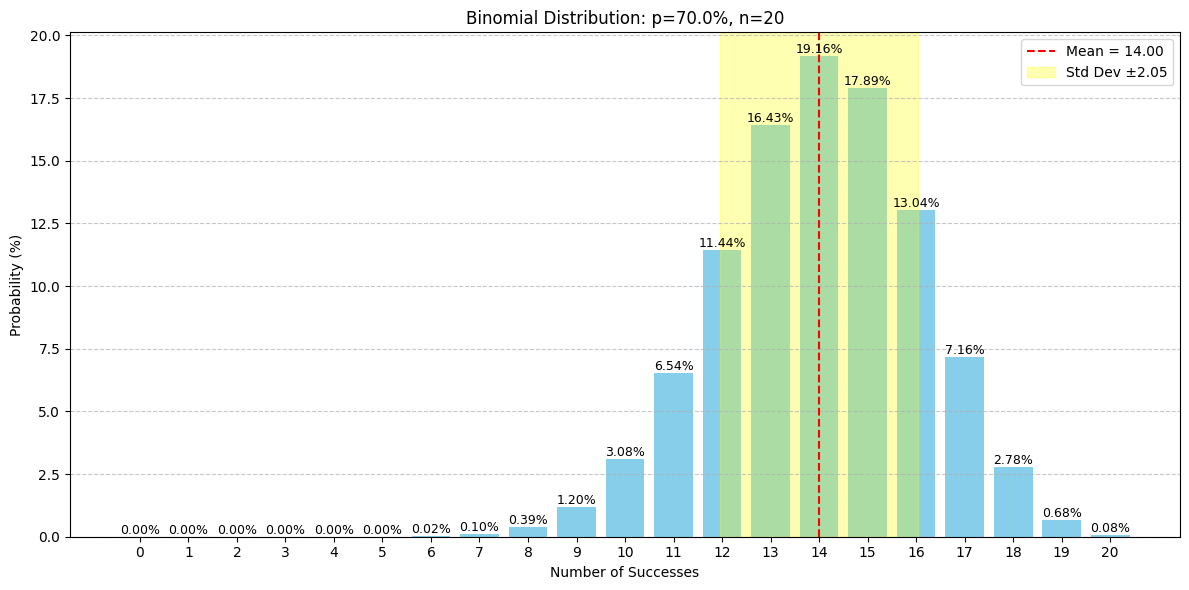

In [1]:
from math import comb
import matplotlib.pyplot as plt
from collections import defaultdict

# Входни данни
p = float(input("Enter probability chance (%): ")) / 100
n = int(input("Enter range of Set: "))

# Изчисляване на вероятностите
d = defaultdict(float)
for k in range(n + 1):
    d[k] = (p ** k) * ((1 - p) ** (n - k)) * comb(n, k)

# Сортиране на резултатите
sorted_d = dict(sorted(d.items(), key=lambda kvp: (-kvp[1], kvp[0])))

# Визуализация
plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_d.keys(), [v * 100 for v in sorted_d.values()], color='skyblue')

# Добавяне на стойности над стълбовете
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=9)

# Настройки на графиката
plt.title(f'Binomial Distribution: p={p * 100:.1f}%, n={n}')
plt.xlabel('Number of Successes')
plt.ylabel('Probability (%)')
plt.xticks(list(sorted_d.keys()))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Статистически характеристики
mean = n * p
variance = n * p * (1 - p)
std_dev = variance ** 0.5

plt.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.2f}')
plt.axvspan(mean - std_dev, mean + std_dev, color='yellow', alpha=0.3,
            label=f'Std Dev ±{std_dev:.2f}')

plt.legend()
plt.tight_layout()
plt.show()
